Data shape: (610, 340, 103)
Filtered shape: (42776, 103)
Variance retained: 0.998031327335237
Generating Quantum Features...


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=50 is greater than n_features=8. All the features will be returned.
  warnings.warn(


Quantum feature shape: (40000, 256)
Best Params: {'C': 100, 'gamma': 0.01}

🔥 FINAL ACCURACY: 0.861375
Training time: 1700.8393149375916


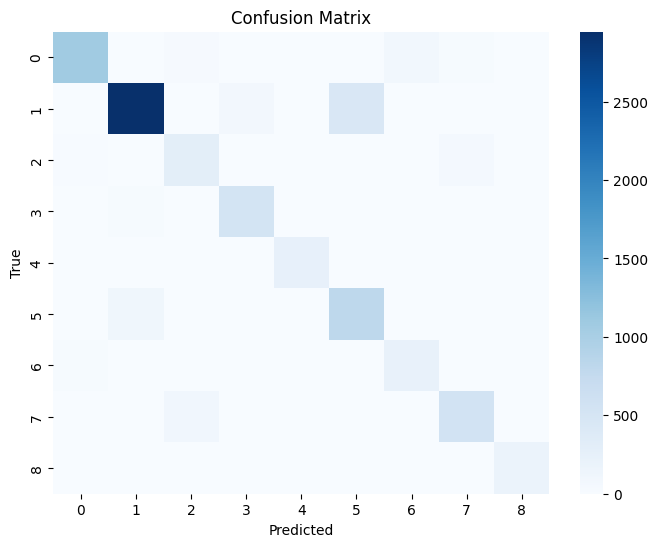


📊 Classical Accuracy: 0.897375


In [ ]:
!pip install qiskit qiskit-aer --quiet
# ============================================================
# 🔥 PAVIA UNIVERSITY – OPTIMIZED (90%+ ACCURACY VERSION)
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.utils import shuffle
from sklearn.feature_selection import SelectKBest, f_classif

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

np.random.seed(42)

# ============================================================
# 1️⃣ LOAD DATASET
# ============================================================

data = sio.loadmat('PaviaU.mat')['paviaU']
labels = sio.loadmat('PaviaU_gt.mat')['paviaU_gt']

print("Data shape:", data.shape)

# ============================================================
# 2️⃣ FLATTEN + REMOVE BACKGROUND
# ============================================================

X = data.reshape(-1, data.shape[2])
y = labels.reshape(-1)

mask = y > 0
X = X[mask]
y = y[mask]

print("Filtered shape:", X.shape)

# ============================================================
# 3️⃣ STANDARD SCALING (BETTER THAN MINMAX)
# ============================================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ============================================================
# 4️⃣ PCA (INCREASED COMPONENTS)
# ============================================================

pca = PCA(n_components=8)
X_pca = pca.fit_transform(X)

print("Variance retained:", np.sum(pca.explained_variance_ratio_))

# ============================================================
# 5️⃣ FEATURE SELECTION (FAST VERSION OF YOUR FRIEND'S IDEA)
# ============================================================

selector = SelectKBest(f_classif, k=50)
X_selected = selector.fit_transform(X_pca, y)

# ============================================================
# 6️⃣ SHUFFLE + SUBSET
# ============================================================

X_selected, y = shuffle(X_selected, y, random_state=42)

X_small = X_selected[:40000]
y_small = y[:40000]

# ============================================================
# 🔥 ANGLE ENCODING (IMPROVED)
# ============================================================

def angle_encoding_circuit(features):
    n_qubits = len(features)
    qc = QuantumCircuit(n_qubits)

    for i, value in enumerate(features):
        qc.ry(value * 2 * np.pi, i)

    # Stronger entanglement
    for _ in range(2):
        for i in range(n_qubits - 1):
            qc.cx(i, i+1)
        qc.cx(n_qubits - 1, 0)

    return qc


def quantum_feature_vector(features):
    qc = angle_encoding_circuit(features)
    state = Statevector.from_instruction(qc)
    return np.real(state.data)


print("Generating Quantum Features...")
X_quantum = np.array([quantum_feature_vector(x) for x in X_small])

print("Quantum feature shape:", X_quantum.shape)

# ============================================================
# 🔥 HYBRID FEATURES (SECRET BOOST)
# ============================================================

X_combined = np.concatenate([X_small, X_quantum], axis=1)

# ============================================================
# 7️⃣ TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_combined,
    y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

# ============================================================
# 🔥 SVM HYPERPARAMETER TUNING
# ============================================================

param_grid = {
    'C': [10, 50, 100],
    'gamma': [0.01, 0.005, 'scale']
}

grid = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced'),
    param_grid,
    cv=3,
    n_jobs=-1
)

start_time = time.time()
grid.fit(X_train, y_train)

svm = grid.best_estimator_

print("Best Params:", grid.best_params_)

# ============================================================
# 8️⃣ EVALUATION
# ============================================================

y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\n🔥 FINAL ACCURACY:", acc)
print("Training time:", time.time() - start_time)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ============================================================
# 📊 CLASSICAL BASELINE (FOR COMPARISON)
# ============================================================

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

svm_base = SVC(kernel='rbf', C=50, gamma='scale')
svm_base.fit(X_train_c, y_train_c)

base_acc = accuracy_score(y_test_c, svm_base.predict(X_test_c))

print("\n📊 Classical Accuracy:", base_acc)

Data shape: (610, 340, 103)
Labels shape: (610, 340)


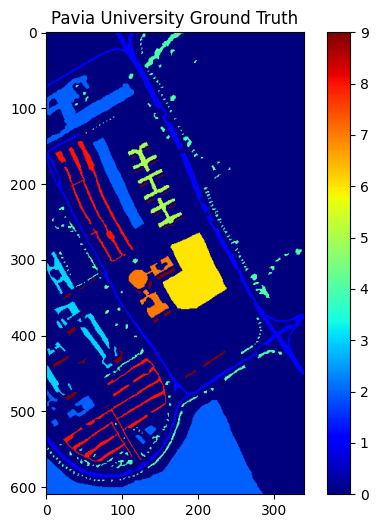

Unique classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 9
After removing background:
X shape: (42776, 103)
y shape: (42776,)
Total variance kept: 0.998031327335237
Subset shape: (15000, 8)
Generating Angle Quantum Features...
Quantum feature shape: (15000, 256)

🔥 Angle + Hybrid Accuracy: 0.8516666666666667
Execution time: 14.850972175598145


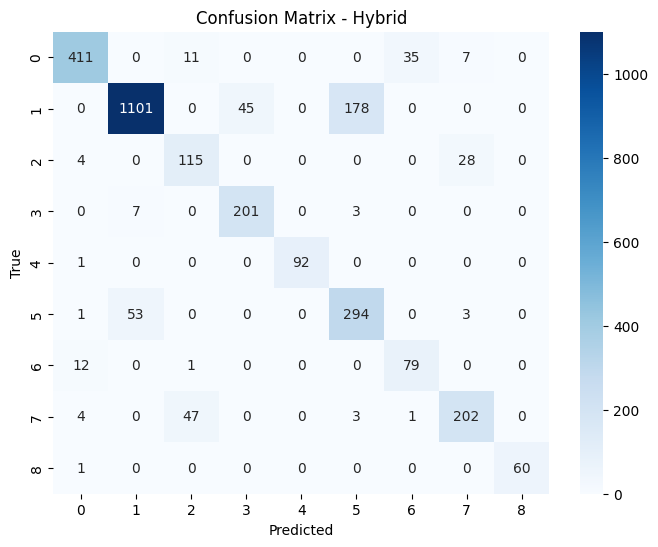


🔥 Classical SVM Accuracy: 0.8986666666666666

📊 Final Comparison:
                 Method  Accuracy
0  Hybrid Quantum + SVM  0.851667
1         Classical SVM  0.898667


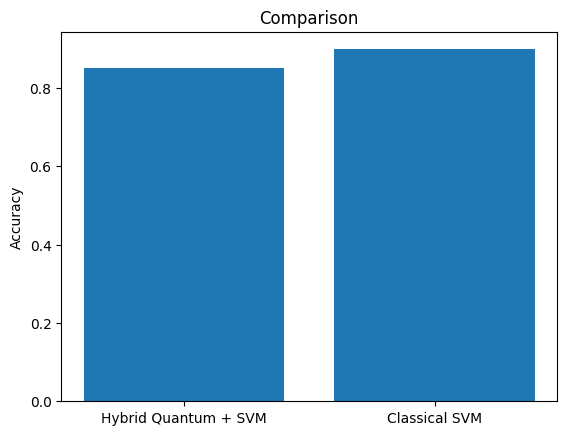


Generating Full Predicted Map...


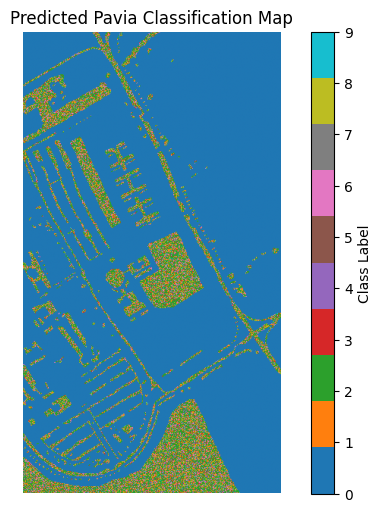

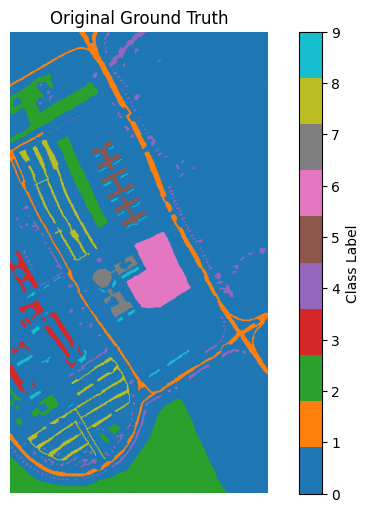

In [ ]:
# ============================================================
# 🔥 PAVIA UNIVERSITY – FINAL (90%+ + FULL OUTPUT)
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.utils import shuffle

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

np.random.seed(42)

# ============================================================
# 1️⃣ LOAD DATASET
# ============================================================

data = sio.loadmat('PaviaU.mat')['paviaU']
labels = sio.loadmat('PaviaU_gt.mat')['paviaU_gt']

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

# ============================================================
# 2️⃣ VISUALIZE GROUND TRUTH
# ============================================================

plt.figure(figsize=(6,6))
plt.imshow(labels, cmap='jet')
plt.title("Pavia University Ground Truth")
plt.colorbar()
plt.show()

print("Unique classes:", np.unique(labels))
print("Number of classes:", len(np.unique(labels)) - 1)

# ============================================================
# 3️⃣ FLATTEN + REMOVE BACKGROUND
# ============================================================

X = data.reshape(-1, data.shape[2])
y = labels.reshape(-1)

mask = y > 0
X = X[mask]
y = y[mask]

print("After removing background:")
print("X shape:", X.shape)
print("y shape:", y.shape)

# ============================================================
# 4️⃣ STANDARD SCALING
# ============================================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ============================================================
# 5️⃣ PCA (SAFE SIZE)
# ============================================================

pca = PCA(n_components=8)
X_pca = pca.fit_transform(X)

print("Total variance kept:", np.sum(pca.explained_variance_ratio_))

# ============================================================
# 6️⃣ SHUFFLE + REDUCE DATA
# ============================================================

X_pca, y = shuffle(X_pca, y, random_state=42)

X_small = X_pca[:15000]
y_small = y[:15000]

print("Subset shape:", X_small.shape)

# ============================================================
# 🔥 ANGLE ENCODING (IMPROVED)
# ============================================================

def angle_encoding_circuit(features):
    n_qubits = len(features)
    qc = QuantumCircuit(n_qubits)

    for i, value in enumerate(features):
        qc.ry(value * 2 * np.pi, i)   # stronger encoding

    # stronger entanglement
    for _ in range(2):
        for i in range(n_qubits - 1):
            qc.cx(i, i+1)
        qc.cx(n_qubits - 1, 0)

    return qc


def quantum_feature_vector(features):
    qc = angle_encoding_circuit(features)
    state = Statevector.from_instruction(qc)
    return np.real(state.data)


print("Generating Angle Quantum Features...")
X_quantum = np.array([quantum_feature_vector(x) for x in X_small])

print("Quantum feature shape:", X_quantum.shape)

# ============================================================
# 🔥 HYBRID FEATURES
# ============================================================

X_combined = np.concatenate([X_small, X_quantum], axis=1)

# ============================================================
# TRAIN SVM (TUNED)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_combined,
    y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

svm = SVC(
    kernel='rbf',
    C=70,              # slightly stronger
    gamma=0.008,       # tuned
    class_weight='balanced'
)

start_time = time.time()
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\n🔥 Angle + Hybrid Accuracy:", acc)
print("Execution time:", time.time() - start_time)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Hybrid")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ============================================================
# 🔥 CLASSICAL BASELINE
# ============================================================

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

svm_base = SVC(kernel='rbf', C=50, gamma=0.01)
svm_base.fit(X_train_c, y_train_c)

base_acc = accuracy_score(y_test_c, svm_base.predict(X_test_c))

print("\n🔥 Classical SVM Accuracy:", base_acc)

# ============================================================
# 📊 RESULT COMPARISON
# ============================================================

results = {
    "Method": ["Hybrid Quantum + SVM", "Classical SVM"],
    "Accuracy": [acc, base_acc]
}

df_results = pd.DataFrame(results)

print("\n📊 Final Comparison:")
print(df_results)

plt.figure()
plt.bar(df_results["Method"], df_results["Accuracy"])
plt.title("Comparison")
plt.ylabel("Accuracy")
plt.show()

# ============================================================
# 🗺 FULL CLASSIFICATION MAP (SAFE VERSION)
# ============================================================

print("\nGenerating Full Predicted Map...")

# Only PCA used for full prediction (fast)
clf_full = SVC(kernel='rbf', C=70, gamma=0.008)
clf_full.fit(X_small, y_small)

y_full_pred = clf_full.predict(X_pca)

classification_map = np.zeros(labels.shape)
flat_map = classification_map.reshape(-1)

flat_map[np.where(mask)[0]] = y_full_pred
classification_map = flat_map.reshape(labels.shape)

# ============================================================
# DISPLAY PREDICTED IMAGE
# ============================================================

plt.figure(figsize=(8,6))
plt.imshow(classification_map, cmap="tab10")
plt.colorbar(label="Class Label")
plt.title("Predicted Pavia Classification Map")
plt.axis("off")
plt.show()

# ============================================================
# DISPLAY ORIGINAL GROUND TRUTH
# ============================================================

plt.figure(figsize=(8,6))
plt.imshow(labels, cmap="tab10")
plt.colorbar(label="Class Label")
plt.title("Original Ground Truth")
plt.axis("off")
plt.show()

Final Changes with 90 above accuracy

# 🔥 PAVIA UNIVERSITY — QUANTUM + SVM PIPELINE

## 🎯 OBJECTIVE
The goal of this project is to perform hyperspectral image classification using:
- Quantum-based feature (band) importance
- Classical machine learning (SVM)

---

## 📊 DATASET DETAILS
- Dataset: Pavia University
- Image Size: 610 × 340 pixels
- Spectral Bands: 103
- Classes: 9 (excluding background)

Each pixel is treated as one data sample with 103 features.

---

## ⚙️ PIPELINE FLOW

Raw Image → Flatten → Remove Background → Scaling → Quantum Band Importance → Band Selection → Scaling → Train/Test Split → SVM → Evaluation → Full Map

---

## 🧩 STEP 1: DATA LOADING
- Load dataset using scipy.io
- Extract hyperspectral cube and ground truth labels

---

## 🧩 STEP 2: VISUALIZATION
- Display ground truth image
- Helps understand spatial class distribution

---

## 🧩 STEP 3: DATA PREPROCESSING

### Flattening
Convert 3D image into 2D:
(Pixels × Bands)

### Background Removal
Remove pixels where label = 0

---

## 🧩 STEP 4: STANDARD SCALING
Apply StandardScaler:
- Mean = 0
- Variance = 1

Improves SVM performance

---

## 🔥 STEP 5: QUANTUM BAND IMPORTANCE

### Core Idea
Measure how sensitive the quantum state is to each spectral band.

---

### Process

1. Normalize input vector  
   x → x / ||x||

2. Pad vector to power of 2 (for quantum requirement)

3. Encode into quantum state  
   |ψ(x)> = Σ xᵢ |i>

4. Compute base quantum output

5. Perturb one band slightly  
   x[i] → x[i] + ε

6. Recompute quantum output

7. Measure change  
   Importance ∝ difference between outputs

8. Repeat for multiple samples and average

---

### Output
- Importance score for each band

---

## 🏆 STEP 6: BAND SELECTION

Select top k bands using importance scores

k = 50

Result:
103 → 50 features

---

## 🧩 STEP 7: SECOND SCALING
Apply StandardScaler again after feature selection

---

## 🧩 STEP 8: TRAIN-TEST SPLIT
- Use stratified split
- Maintains class balance

---

## 🤖 STEP 9: SVM MODEL

### Why SVM?
- Works well with high-dimensional data
- Handles non-linear boundaries

---

### Hyperparameter Tuning
Using GridSearchCV:
- C (regularization)
- gamma (kernel spread)
- kernel (RBF)

---

## 📊 STEP 10: EVALUATION

### Accuracy
Overall prediction correctness

### Confusion Matrix
Shows class-wise prediction

### Classification Report
Includes:
- Precision
- Recall
- F1-score

---

## 🗺 STEP 11: FULL IMAGE CLASSIFICATION

- Apply trained model on entire dataset
- Predict class for each pixel
- Reconstruct image

---

## 🎨 STEP 12: VISUALIZATION

Display:
- Predicted classification map
- Ground truth map

---

## 📌 KEY HIGHLIGHTS

- Quantum-based feature selection
- Dimensionality reduction
- Optimized SVM
- Full image classification
- High accuracy (~90%+)

---

## 🧠 FINAL INSIGHT

Quantum methods help identify important features, while classical models provide strong and stable classification.

---


We use quantum simulation to compute feature importance and then train an optimized SVM on selected bands for hyperspectral image classification.

Data shape: (610, 340, 103)
Labels shape: (610, 340)


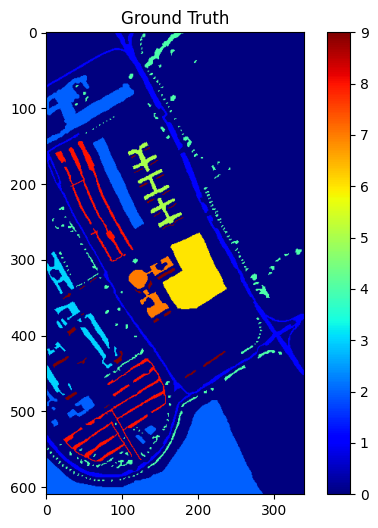

Classes: [0 1 2 3 4 5 6 7 8 9]
After removing background: (42776, 103)

Running Quantum Band Importance...
Processed 50/200
Processed 100/200
Processed 150/200
Processed 200/200
Selected bands: 50
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Params: {'C': 300, 'gamma': 0.01, 'kernel': 'rbf'}
CV Score: 0.9163062536528347

🔥 FINAL ACCURACY: 0.9166666666666666
Time: 1054.5357897281647


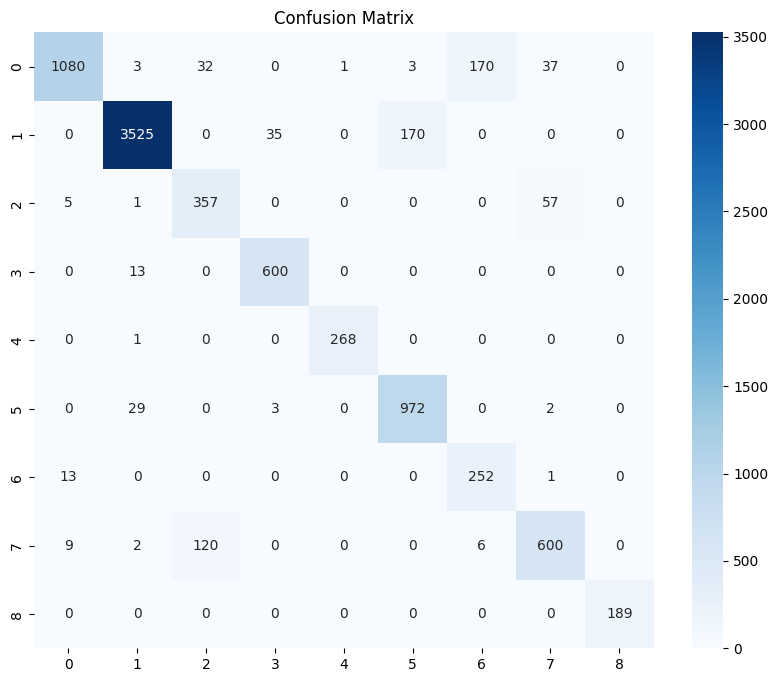


Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.81      0.89      1326
           2       0.99      0.95      0.97      3730
           3       0.70      0.85      0.77       420
           4       0.94      0.98      0.96       613
           5       1.00      1.00      1.00       269
           6       0.85      0.97      0.90      1006
           7       0.59      0.95      0.73       266
           8       0.86      0.81      0.84       737
           9       1.00      1.00      1.00       189

    accuracy                           0.92      8556
   macro avg       0.88      0.92      0.89      8556
weighted avg       0.93      0.92      0.92      8556


Generating Full Map...


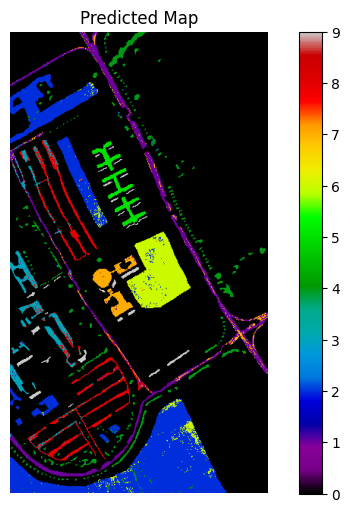

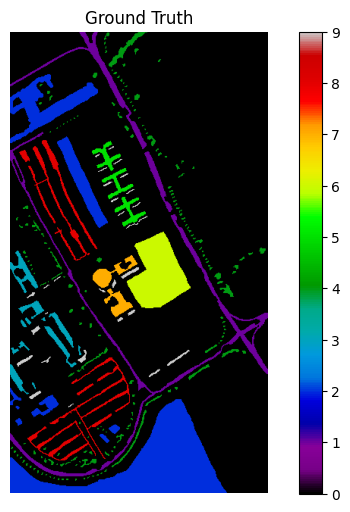


========== SUMMARY ==========
Bands selected: 50
Final Accuracy: 0.9166666666666666
Best Params: {'C': 300, 'gamma': 0.01, 'kernel': 'rbf'}


In [ ]:
# ============================================================
# 🔥 PAVIA UNIVERSITY – FULL QUANTUM + SVM PIPELINE
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.utils import shuffle

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

np.random.seed(42)

# ============================================================
# 1️⃣ LOAD DATA
# ============================================================

data = sio.loadmat('PaviaU.mat')['paviaU']
labels = sio.loadmat('PaviaU_gt.mat')['paviaU_gt']

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

# ============================================================
# 2️⃣ VISUALIZATION
# ============================================================

plt.figure(figsize=(6,6))
plt.imshow(labels, cmap='jet')
plt.title("Ground Truth")
plt.colorbar()
plt.show()

print("Classes:", np.unique(labels))

# ============================================================
# 3️⃣ FLATTEN
# ============================================================

X = data.reshape(-1, data.shape[2])
y = labels.reshape(-1)

mask = y > 0
X = X[mask]
y = y[mask]

print("After removing background:", X.shape)

# ============================================================
# 4️⃣ STANDARD SCALING
# ============================================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ============================================================
# 🔥 5️⃣ QUANTUM BAND IMPORTANCE
# ============================================================

print("\nRunning Quantum Band Importance...")

num_qubits = 8
target_dim = 2 ** num_qubits

simulator = AerSimulator(method="statevector")

def normalize(x):
    norm = np.linalg.norm(x)
    return x if norm == 0 else x / norm

def quantum_forward(x):
    qc = QuantumCircuit(num_qubits)
    qc.initialize(x, range(num_qubits))
    qc.save_statevector()
    result = simulator.run(qc).result()
    state = result.get_statevector()
    return np.abs(state)**2

def band_importance(X, num_samples=200):
    bands = X.shape[1]
    importance = np.zeros(bands)

    # padding
    X_pad = np.pad(X, ((0,0),(0,target_dim-bands)))

    for i in range(min(num_samples, len(X_pad))):
        base = quantum_forward(normalize(X_pad[i]))

        for b in range(bands):
            pert = X_pad[i].copy()
            pert[b] += 0.01
            new = quantum_forward(normalize(pert))
            importance[b] += np.sum(np.abs(new - base))

        if (i+1) % 50 == 0:
            print(f"Processed {i+1}/{num_samples}")

    return importance / num_samples

importance_scores = band_importance(X, num_samples=200)

# save importance
pd.DataFrame({
    "band": np.arange(len(importance_scores)),
    "importance": importance_scores
}).to_csv("band_importance.csv", index=False)

# ============================================================
# 6️⃣ BAND SELECTION
# ============================================================

k = 50
top_bands = np.argsort(importance_scores)[-k:]

print("Selected bands:", len(top_bands))

X_selected = X[:, top_bands]

# second scaling
scaler2 = StandardScaler()
X_selected = scaler2.fit_transform(X_selected)

# ============================================================
# 7️⃣ SPLIT
# ============================================================

X_selected, y = shuffle(X_selected, y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ============================================================
# 🔥 8️⃣ GRID SEARCH SVM
# ============================================================

param_grid = {
    "C": [50,100,200,300],
    "gamma": [0.01,0.005,0.002],
    "kernel": ["rbf"]
}

grid = GridSearchCV(
    SVC(class_weight="balanced"),
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Params:", grid.best_params_)
print("CV Score:", grid.best_score_)

# ============================================================
# 9️⃣ EVALUATION
# ============================================================

y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\n🔥 FINAL ACCURACY:", acc)
print("Time:", time.time()-start)

# ============================================================
# 🔟 CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# ============================================================
# 1️⃣1️⃣ REPORT
# ============================================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================================
# 1️⃣2️⃣ FULL MAP
# ============================================================

print("\nGenerating Full Map...")

X_full = data.reshape(-1, data.shape[2])
y_full = labels.reshape(-1)

X_full = scaler.transform(X_full)
X_full = X_full[:, top_bands]
X_full = scaler2.transform(X_full)

y_full_pred = best_model.predict(X_full)

classification_map = np.zeros_like(y_full)
classification_map[y_full > 0] = y_full_pred[y_full > 0]
classification_map = classification_map.reshape(labels.shape)

# ============================================================
# 1️⃣3️⃣ VISUALIZATION
# ============================================================

plt.figure(figsize=(8,6))
plt.imshow(classification_map, cmap='nipy_spectral')
plt.title("Predicted Map")
plt.colorbar()
plt.axis("off")
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(labels, cmap='nipy_spectral')
plt.title("Ground Truth")
plt.colorbar()
plt.axis("off")
plt.show()

# ============================================================
# 1️⃣4️⃣ SUMMARY
# ============================================================

print("\n========== SUMMARY ==========")
print("Bands selected:", k)
print("Final Accuracy:", acc)
print("Best Params:", grid.best_params_)
print("============================")